In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/biohub-cell-tracking-during-development/sample_submission.csv
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/zarr.json
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/zarr.json
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/7/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/47/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/17/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/81/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/19/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/22/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845

# Biohub – Cell Tracking During Development

## Chapter 10: Building a Filtered Detector from Ranked Candidates

**Objective:** Use the Chapter 9 candidate-ranking model to turn the noisy LoG candidate pool into a practical filtered detector and evaluate multiple top-k cutoffs.

# 🎯 Learning Objectives

By the end of this notebook, I will be able to:

- score LoG candidate detections using the Chapter 9 GT-like ranking model
- build filtered candidate sets using top-k thresholds
- compare recall and precision-like behavior across multiple cutoffs
- visualize how filtering changes the detector output
- choose a first practical filtered-detector configuration

# 🧠 Background Theory

In Chapter 7, LoG blob detection improved recall but produced far too many candidate detections.

In Chapter 8, I compared matched and unmatched blob detections and found that simple brightness features alone were not enough to separate them well.

In Chapter 9, I trained a candidate-ranking model and found that the top-ranked candidates were much more enriched for GT-like detections than the raw LoG pool.

In this notebook, I will turn that ranking model into a filtered detector by keeping only the top-scoring candidates and evaluating several cutoff choices.

# 🗺️ Chapter Roadmap

This notebook will proceed in six stages:

1. **Reload the sample and ground truth**
2. **Recreate the LoG candidate pool**
3. **Rebuild the Chapter 9 candidate-ranking model**
4. **Score all candidates with a GT-like score**
5. **Evaluate filtered candidate sets at multiple top-k thresholds**
6. **Visualize the filtered detections and choose a first detector configuration**

# 📚 New Vocabulary

## Filtered Detector
A detector created by keeping only the top-ranked candidate detections from a larger candidate pool.

## Top-k Filtering
Keeping only the top `k` candidates according to a ranking score.

## Candidate Pool
The full set of raw detections produced by the LoG blob detector before filtering.

In [2]:
!pip install zarr -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 85.3 MB/s eta 0:00:00


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr

from skimage.feature import blob_log
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [4]:
print("Imports successful.")

Imports successful.


# Step 1 — Reload the Same Sample and Ground Truth

To keep the detector comparison consistent, I will continue using the same sample and timepoint from Chapters 7–9.

In [5]:
competition_path = Path("/kaggle/input/competitions/biohub-cell-tracking-during-development")
train_path = competition_path / "train"

sample_id = "44b6_12dfb391"
zarr_path = train_path / f"{sample_id}.zarr"
geff_path = train_path / f"{sample_id}.geff"

# Load image
volume = zarr.open(zarr_path, mode="r")
image = volume["0"]

# Load graph
geff = zarr.open(geff_path, mode="r")

node_ids = geff["nodes/ids"][:]
t_vals = geff["nodes/props/t/values"][:]
z_vals = geff["nodes/props/z/values"][:]
y_vals = geff["nodes/props/y/values"][:]
x_vals = geff["nodes/props/x/values"][:]

nodes_df = pd.DataFrame({
    "node_id": node_ids,
    "t": t_vals,
    "z": z_vals,
    "y": y_vals,
    "x": x_vals
})

t = 8
frame_3d = image[t]
gt_nodes_t = nodes_df[nodes_df["t"] == t].copy().sort_values("z")
gt_points = gt_nodes_t[["z", "y", "x"]].to_numpy()

print("Frame shape:", frame_3d.shape)
print("Ground-truth nodes:", len(gt_nodes_t))
gt_nodes_t

Frame shape: (64, 256, 256)
Ground-truth nodes: 11


,node_id,t,z,y,x
82,114000000041,8,10,237,65
81,114000000040,8,15,184,60
87,114000000080,8,17,248,101
90,114000000084,8,18,2,116
89,114000000082,8,22,199,63
84,114000000043,8,25,208,115
83,114000000042,8,27,156,0
88,114000000081,8,28,122,100
80,114000000037,8,37,50,192
86,114000000063,8,40,198,98


# Step 2 — Recreate the LoG Candidate Pool

I will rebuild the same LoG candidate pool and candidate-feature table used in Chapter 9 so that I can score and filter the detections.

In [6]:
def detect_blobs_log_3d_slicewise(
    frame_3d,
    min_sigma=2.5,
    max_sigma=3.5,
    num_sigma=3,
    threshold=0.15
):
    detections = []

    for z in range(frame_3d.shape[0]):
        slice_2d = frame_3d[z].astype(np.float32)

        s_min, s_max = slice_2d.min(), slice_2d.max()
        if s_max > s_min:
            slice_norm = (slice_2d - s_min) / (s_max - s_min)
        else:
            slice_norm = slice_2d

        blobs = blob_log(
            slice_norm,
            min_sigma=min_sigma,
            max_sigma=max_sigma,
            num_sigma=num_sigma,
            threshold=threshold
        )

        for blob in blobs:
            y, x, sigma = blob
            detections.append({
                "z": int(z),
                "y": int(round(y)),
                "x": int(round(x)),
                "sigma": float(sigma)
            })

    return pd.DataFrame(detections)

In [7]:
def pairwise_distances_3d(gt_points, pred_points):
    gt = gt_points[:, None, :]
    pred = pred_points[None, :, :]
    distances = np.sqrt(((gt - pred) ** 2).sum(axis=2))
    return distances

In [8]:
def extract_candidate_features(frame_3d, detections_df, patch_radius=4):
    rows = []
    z_max, y_max, x_max = frame_3d.shape

    for _, row in detections_df.iterrows():
        z = int(row["z"])
        y = int(row["y"])
        x = int(row["x"])

        slice_2d = frame_3d[z].astype(np.float32)

        # ----- 2D patch -----
        y0 = max(0, y - patch_radius)
        y1 = min(y_max, y + patch_radius + 1)
        x0 = max(0, x - patch_radius)
        x1 = min(x_max, x + patch_radius + 1)

        patch = slice_2d[y0:y1, x0:x1]

        center_intensity = float(slice_2d[y, x])
        patch_mean = float(patch.mean())
        patch_max = float(patch.max())
        patch_std = float(patch.std())
        local_contrast = center_intensity - patch_mean

        # brightest pixel location in patch
        max_idx = np.unravel_index(np.argmax(patch), patch.shape)
        max_y_patch, max_x_patch = max_idx

        patch_center_y = y - y0
        patch_center_x = x - x0

        center_to_patch_max_dist = float(
            np.sqrt((max_y_patch - patch_center_y)**2 + (max_x_patch - patch_center_x)**2)
        )

        # center of mass
        yy, xx = np.indices(patch.shape)
        patch_sum = patch.sum()

        if patch_sum > 0:
            com_y = float((yy * patch).sum() / patch_sum)
            com_x = float((xx * patch).sum() / patch_sum)
            patch_com_offset = float(
                np.sqrt((com_y - patch_center_y)**2 + (com_x - patch_center_x)**2)
            )
        else:
            patch_com_offset = np.nan

        # border feature
        border_margin = min(y, x, y_max - 1 - y, x_max - 1 - x)
        is_near_border = int(border_margin < patch_radius)

        # z-support
        z_vals_local = []
        for zz in [z - 1, z, z + 1]:
            if 0 <= zz < z_max:
                z_vals_local.append(float(frame_3d[zz, y, x]))

        z_center_intensity = float(frame_3d[z, y, x])
        z_support_mean = float(np.mean(z_vals_local))
        z_support_std = float(np.std(z_vals_local))
        z_support_min = float(np.min(z_vals_local))
        z_support_max = float(np.max(z_vals_local))

        rows.append({
            "z": z,
            "y": y,
            "x": x,
            "sigma": float(row["sigma"]),
            "nearest_gt_dist": float(row["nearest_gt_dist"]),
            "matched": bool(row["matched"]),

            "center_intensity": center_intensity,
            "patch_mean": patch_mean,
            "patch_max": patch_max,
            "patch_std": patch_std,
            "local_contrast": local_contrast,

            "center_to_patch_max_dist": center_to_patch_max_dist,
            "patch_com_offset": patch_com_offset,
            "is_near_border": is_near_border,

            "z_center_intensity": z_center_intensity,
            "z_support_mean": z_support_mean,
            "z_support_std": z_support_std,
            "z_support_min": z_support_min,
            "z_support_max": z_support_max,
        })

    return pd.DataFrame(rows)

In [9]:
blob_df = detect_blobs_log_3d_slicewise(frame_3d)

blob_points = blob_df[["z", "y", "x"]].to_numpy()
dist_blob = pairwise_distances_3d(gt_points, blob_points)

min_dist_pred = dist_blob.min(axis=0)
match_radius = 6

blob_df["nearest_gt_dist"] = min_dist_pred
blob_df["matched"] = blob_df["nearest_gt_dist"] <= match_radius

candidate_df = extract_candidate_features(frame_3d, blob_df, patch_radius=4)

print("Candidate rows:", len(candidate_df))
print(candidate_df["matched"].value_counts())
candidate_df.head()

Candidate rows: 1478
matched
False    1453
True       25
Name: count, dtype: int64


,z,y,x,sigma,nearest_gt_dist,matched,center_intensity,patch_mean,patch_max,patch_std,local_contrast,center_to_patch_max_dist,patch_com_offset,is_near_border,z_center_intensity,z_support_mean,z_support_std,z_support_min,z_support_max
0,0,92,0,3.5,69.462220,False,1280.0,907.822205,1280.0,174.333572,372.177795,0.000000,1.851372,1,1280.0,1438.5,158.5,1280.0,1597.0
1,0,183,6,3.5,38.652296,False,1250.0,1016.234558,1286.0,158.421249,233.765442,1.000000,0.162069,0,1250.0,1121.5,128.5,993.0,1250.0
2,0,118,19,3.5,50.338852,False,867.0,742.172852,920.0,97.855751,124.827148,1.414214,0.161427,0,867.0,978.5,111.5,867.0,1090.0
3,0,212,75,3.5,28.231188,False,1028.0,864.765442,1050.0,113.143227,163.234558,1.000000,0.166543,0,1028.0,891.0,137.0,754.0,1028.0
4,0,208,19,3.5,49.819675,False,885.0,822.703674,928.0,76.585213,62.296326,5.656854,0.130084,0,885.0,895.0,10.0,885.0,905.0


# Step 3 — Rebuild the Candidate-Ranking Model

I will retrain the Chapter 9 candidate filter so I can score every LoG candidate with a GT-like score.

In [10]:
feature_cols = [
    "sigma",
    "center_intensity",
    "patch_mean",
    "patch_max",
    "patch_std",
    "local_contrast",
    "center_to_patch_max_dist",
    "patch_com_offset",
    "is_near_border",
    "z_center_intensity",
    "z_support_mean",
    "z_support_std",
    "z_support_min",
    "z_support_max",
]

X = candidate_df[feature_cols]
y = candidate_df["matched"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    max_depth=6
)

clf.fit(X_train, y_train)

print("Ranking model rebuilt.")

Ranking model rebuilt.


# Step 4 — Score Every Candidate with a GT-Like Score

Now I will score every LoG candidate using the ranking model and sort detections from most GT-like to least GT-like.

In [11]:
candidate_df = candidate_df.copy()
candidate_df["gt_like_score"] = clf.predict_proba(candidate_df[feature_cols])[:, 1]

ranked_df = candidate_df.sort_values("gt_like_score", ascending=False)

ranked_df.head(20)

,z,y,x,sigma,nearest_gt_dist,matched,center_intensity,patch_mean,patch_max,patch_std,local_contrast,center_to_patch_max_dist,patch_com_offset,is_near_border,z_center_intensity,z_support_mean,z_support_std,z_support_min,z_support_max,gt_like_score
274,17,245,99,3.5,3.605551,True,1493.0,1213.061768,1493.0,141.490509,279.938232,0.000000,0.046691,0,1493.0,1348.666667,117.173186,1206.0,1493.0,0.705798
94,8,234,64,3.5,3.741657,True,1437.0,1152.419800,1470.0,185.886795,284.580200,1.000000,0.113143,0,1437.0,1362.000000,92.285788,1232.0,1437.0,0.701110
523,26,209,118,3.5,3.316625,True,1463.0,1296.814819,1523.0,116.985077,166.185181,4.123106,0.118907,0,1463.0,1370.666667,127.761062,1190.0,1463.0,0.691575
251,16,183,57,3.5,3.316625,True,1353.0,1194.716064,1369.0,111.440102,158.283936,1.414214,0.099648,0,1353.0,1289.000000,73.543638,1186.0,1353.0,0.688853
71,7,234,64,3.5,4.358899,True,1417.0,1121.481445,1418.0,164.917633,295.518555,1.414214,0.088469,0,1417.0,1317.333333,155.306865,1098.0,1437.0,0.682034
339,21,197,62,3.5,2.449490,True,1809.0,1581.580200,1834.0,162.448914,227.419800,1.000000,0.020043,0,1809.0,1796.000000,135.442485,1624.0,1955.0,0.676028
250,16,245,99,3.5,3.741657,True,1347.0,1151.604980,1347.0,126.122292,195.395020,0.000000,0.077463,0,1347.0,1289.000000,194.614148,1027.0,1493.0,0.664900
1151,45,117,143,3.5,5.916080,True,1869.0,1600.827148,1943.0,204.413101,268.172852,2.828427,0.107938,0,1869.0,1873.333333,136.797498,1708.0,2043.0,0.653777
1133,44,120,143,3.5,5.744563,True,1911.0,1615.876587,1911.0,167.486008,295.123413,0.000000,0.036428,0,1911.0,1939.000000,249.003347,1649.0,2257.0,0.646166
137,10,240,67,3.5,3.605551,True,1294.0,1105.000000,1294.0,136.249771,189.000000,0.000000,0.164304,0,1294.0,1200.666667,68.397531,1132.0,1294.0,0.641773


# Step 5 — Evaluate Filtered Candidate Sets

I will evaluate several filtered detector configurations by keeping only the top-ranked candidates and measuring how many ground-truth cells they recover.

In [12]:
def evaluate_detector(gt_points, pred_points, match_radius=6):
    if len(pred_points) == 0:
        return {
            "num_gt": len(gt_points),
            "num_pred": 0,
            "gt_detected": 0,
            "gt_missed": len(gt_points),
            "pred_matched": 0,
            "pred_unmatched": 0,
            "gt_recall": 0.0,
            "pred_precision_like": np.nan,
            "min_dist_gt": np.full(len(gt_points), np.inf),
            "min_dist_pred": np.array([]),
            "gt_matched_mask": np.zeros(len(gt_points), dtype=bool),
            "pred_matched_mask": np.array([], dtype=bool),
        }

    dist = pairwise_distances_3d(gt_points, pred_points)

    min_dist_gt = dist.min(axis=1)
    min_dist_pred = dist.min(axis=0)

    gt_matched_mask = min_dist_gt <= match_radius
    pred_matched_mask = min_dist_pred <= match_radius

    gt_detected = gt_matched_mask.sum()
    gt_missed = len(gt_points) - gt_detected

    pred_matched = pred_matched_mask.sum()
    pred_unmatched = len(pred_points) - pred_matched

    return {
        "num_gt": len(gt_points),
        "num_pred": len(pred_points),
        "gt_detected": gt_detected,
        "gt_missed": gt_missed,
        "pred_matched": pred_matched,
        "pred_unmatched": pred_unmatched,
        "gt_recall": gt_detected / len(gt_points),
        "pred_precision_like": pred_matched / len(pred_points),
        "min_dist_gt": min_dist_gt,
        "min_dist_pred": min_dist_pred,
        "gt_matched_mask": gt_matched_mask,
        "pred_matched_mask": pred_matched_mask,
    }

In [13]:
topk_values = [25, 50, 100, 200]

filtered_results = []

for k in topk_values:
    topk_df = ranked_df.head(k).copy()
    pred_points_k = topk_df[["z", "y", "x"]].to_numpy()

    result_k = evaluate_detector(gt_points, pred_points_k, match_radius=6)

    filtered_results.append({
        "top_k": k,
        "num_pred": result_k["num_pred"],
        "gt_detected": result_k["gt_detected"],
        "gt_missed": result_k["gt_missed"],
        "pred_matched": result_k["pred_matched"],
        "pred_unmatched": result_k["pred_unmatched"],
        "gt_recall": result_k["gt_recall"],
        "pred_precision_like": result_k["pred_precision_like"],
        "match_rate_in_topk": topk_df["matched"].mean()
    })

filtered_results_df = pd.DataFrame(filtered_results)
filtered_results_df

,top_k,num_pred,gt_detected,gt_missed,pred_matched,pred_unmatched,gt_recall,pred_precision_like,match_rate_in_topk
0,25,25,6,5,19,6,0.545455,0.76,0.76
1,50,50,6,5,20,30,0.545455,0.40,0.40
2,100,100,7,4,22,78,0.636364,0.22,0.22
3,200,200,7,4,22,178,0.636364,0.11,0.11


In [14]:
raw_log_points = candidate_df[["z", "y", "x"]].to_numpy()
raw_log_eval = evaluate_detector(gt_points, raw_log_points, match_radius=6)

raw_row = pd.DataFrame([{
    "top_k": "raw_log",
    "num_pred": raw_log_eval["num_pred"],
    "gt_detected": raw_log_eval["gt_detected"],
    "gt_missed": raw_log_eval["gt_missed"],
    "pred_matched": raw_log_eval["pred_matched"],
    "pred_unmatched": raw_log_eval["pred_unmatched"],
    "gt_recall": raw_log_eval["gt_recall"],
    "pred_precision_like": raw_log_eval["pred_precision_like"],
    "match_rate_in_topk": candidate_df["matched"].mean()
}])

comparison_df = pd.concat([raw_row, filtered_results_df], ignore_index=True)
comparison_df

,top_k,num_pred,gt_detected,gt_missed,pred_matched,pred_unmatched,gt_recall,pred_precision_like,match_rate_in_topk
0,raw_log,1478,8,3,25,1453,0.727273,0.016915,0.016915
1,25,25,6,5,19,6,0.545455,0.760000,0.760000
2,50,50,6,5,20,30,0.545455,0.400000,0.400000
3,100,100,7,4,22,78,0.636364,0.220000,0.220000
4,200,200,7,4,22,178,0.636364,0.110000,0.110000


# Step 6 — Visualize a Filtered Detector

I will overlay the top-ranked filtered detections on the microscopy slices that contain the ground-truth centroids so I can see how the filtered detector behaves visually.

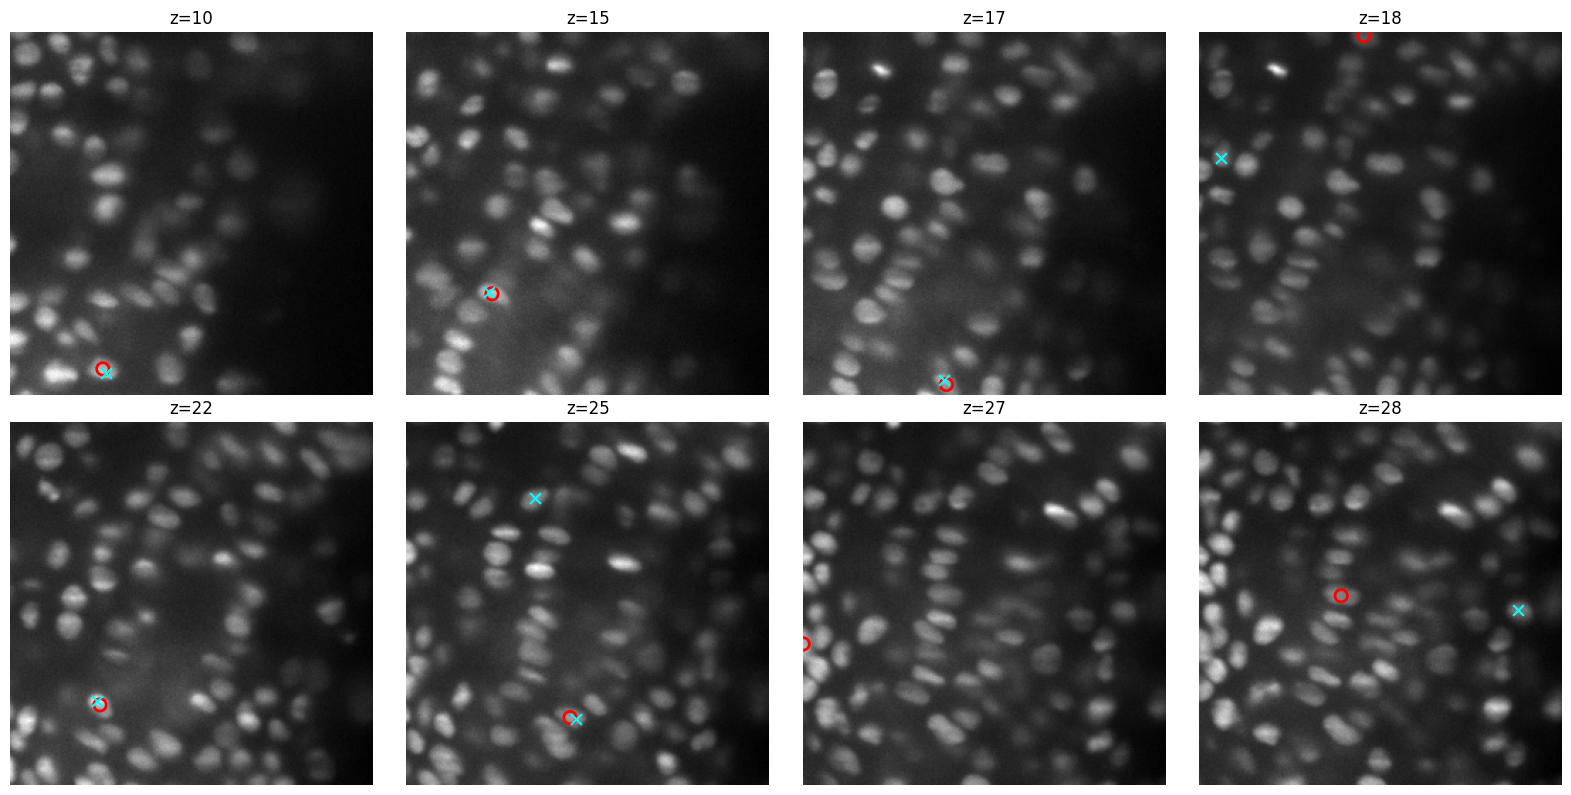

In [15]:
top_k_vis = 50
top_vis_df = ranked_df.head(top_k_vis).copy()

gt_z_slices = sorted(gt_nodes_t["z"].unique())

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, z in zip(axes, gt_z_slices[:8]):
    slice_img = frame_3d[z]
    gt_slice = gt_nodes_t[gt_nodes_t["z"] == z]
    pred_slice = top_vis_df[top_vis_df["z"] == z]

    ax.imshow(slice_img, cmap="gray")

    # GT = red circles
    ax.scatter(gt_slice["x"], gt_slice["y"],
               facecolors="none", edgecolors="red", s=80, linewidths=2, label="GT")

    # top-k filtered predictions = cyan x
    ax.scatter(pred_slice["x"], pred_slice["y"],
               c="cyan", marker="x", s=60, label="filtered pred")

    ax.set_title(f"z={z}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [16]:
best_row = filtered_results_df.sort_values(
    ["gt_recall", "pred_precision_like"],
    ascending=[False, False]
).iloc[0]

best_row

top_k                  100.000000
num_pred               100.000000
gt_detected              7.000000
gt_missed                4.000000
pred_matched            22.000000
pred_unmatched          78.000000
gt_recall                0.636364
pred_precision_like      0.220000
match_rate_in_topk       0.220000
Name: 2, dtype: float64

In [17]:
print("Best filtered detector candidate:")
print(f"top_k = {best_row['top_k']}")
print(f"gt_detected = {best_row['gt_detected']} / {len(gt_points)}")
print(f"gt_recall = {best_row['gt_recall']:.3f}")
print(f"precision_like = {best_row['pred_precision_like']:.3f}")
print(f"match_rate_in_topk = {best_row['match_rate_in_topk']:.3f}")

Best filtered detector candidate:
top_k = 100.0
gt_detected = 7.0 / 11
gt_recall = 0.636
precision_like = 0.220
match_rate_in_topk = 0.220


# 📊 Results

I evaluated filtered detector configurations by keeping only the top-ranked LoG candidates according to the Chapter 9 GT-like score.

## Raw LoG detector
- **1478 predictions**
- **8 / 11 GT detected**
- **GT recall:** 0.727
- **Precision-like:** 0.0169

## Filtered detector results

### Top 25
- **25 predictions**
- **6 / 11 GT detected**
- **GT recall:** 0.545
- **Precision-like:** 0.760

### Top 50
- **50 predictions**
- **6 / 11 GT detected**
- **GT recall:** 0.545
- **Precision-like:** 0.400

### Top 100
- **100 predictions**
- **7 / 11 GT detected**
- **GT recall:** 0.636
- **Precision-like:** 0.220

### Top 200
- **200 predictions**
- **7 / 11 GT detected**
- **GT recall:** 0.636
- **Precision-like:** 0.110

# 🔍 Analysis

The candidate-ranking model successfully turned the noisy LoG candidate pool into a much more practical filtered detector.

## Main findings

### 1. Filtering drastically improved candidate quality
The raw LoG detector produced 1478 candidates with a precision-like score of only 0.0169. After filtering, the top-ranked candidate sets were much more concentrated with GT-like detections.

### 2. There is a clear precision–recall tradeoff
Smaller top-k sets produced higher precision-like scores but lower recall. Larger top-k sets recovered more GT detections but also introduced more unmatched candidates.

### 3. Top 100 was the best balance on this frame
The top-100 filtered detector recovered **7 of 11** GT centroids while maintaining a much smaller and cleaner candidate pool than raw LoG.

### 4. The filtered detector is now practical enough to iterate on
The candidate filter does not fully recover raw LoG recall yet, but it reduces the candidate set dramatically while preserving most of the useful detections.

# 📝 What I Learned

Today I learned that:

- a noisy detector can still be useful if it is paired with a strong ranking/filtering stage
- GT-like ranking can dramatically improve the quality of a candidate pool
- top-k filtering creates a real precision–recall tradeoff that can be tuned depending on the downstream task
- for this frame, a top-100 filtered detector appears to be the best practical starting point

# 🚀 Next Steps

## Chapter 11 — Test the Filtered Detector on More Frames

So far, I have only tuned and evaluated the filtered detector on a single frame (`sample = 44b6_12dfb391`, `t = 8`).

In the next notebook, I want to test whether the same detector pipeline generalizes to other timepoints and other samples.

Goals:
- run the filtered detector on multiple timepoints from the same sample
- compare top-k behavior across frames
- check whether the same features remain useful
- measure whether the ranking model generalizes or needs retraining